In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# 노트북 안에 그래프를 그리기 위해
%matplotlib inline

# 그래프에서 격자로 숫자 범위가 눈에 잘 띄도록 ggplot 스타일을 사용
plt.style.use('ggplot')

# 그래프에서 마이너스 폰트 깨지는 문제에 대한 대처
mpl.rcParams['axes.unicode_minus'] = False

In [4]:
train = pd.read_csv("./train.csv", parse_dates=["datetime"])
test = pd.read_csv("./test.csv", parse_dates=["datetime"])
train.shape, test.shape

((10886, 12), (6493, 9))

In [6]:
train.columns, test.columns

(Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
        'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
       dtype='object'),
 Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
        'atemp', 'humidity', 'windspeed'],
       dtype='object'))

In [10]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [13]:
train.temp.describe()

count    10886.00000
mean        20.23086
std          7.79159
min          0.82000
25%         13.94000
50%         20.50000
75%         26.24000
max         41.00000
Name: temp, dtype: float64

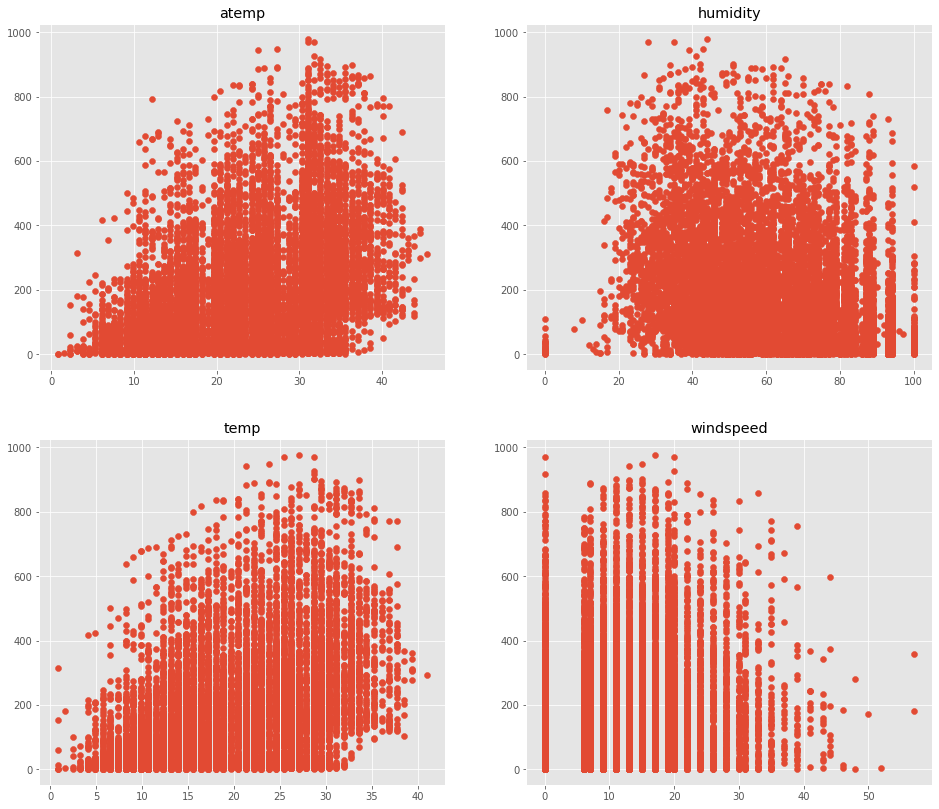

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(16,14))
 
# scatter plot
ax[0][0].scatter(train['atemp'], train['count'])
ax[0][1].scatter(train['humidity'], train['count'])
ax[1][0].scatter(train['temp'], train['count'])
ax[1][1].scatter(train['windspeed'], train['count'])
 
# title 지정
ax[0][0].set(title='atemp')
ax[0][1].set(title='humidity')
ax[1][0].set(title='temp')
ax[1][1].set(title='windspeed')
 
plt.show()

In [17]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'sudo apt autoremove' to remove it.
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 9,604 kB of archives.
After this operation, 29.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic/universe amd64 fonts-nanum all 20170925-1 [9,604 kB]
Fetched 9,604 kB in 1s (9,348 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 76, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype

In [6]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic') 

In [5]:
train["year"] = train["datetime"].dt.year
train["month"] = train["datetime"].dt.month
train["day"] = train["datetime"].dt.day
train["hour"] = train["datetime"].dt.hour
train["minute"] = train["datetime"].dt.minute
train["second"] = train["datetime"].dt.second
train.shape

(10886, 18)

[Text(0.5, 0, 'hour'), Text(0.5, 1.0, '시간별 대여량')]

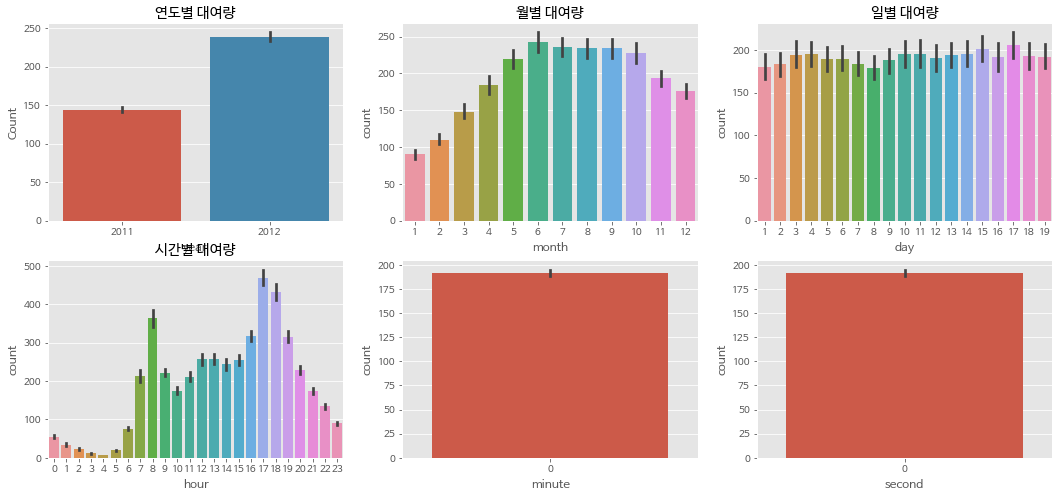

In [7]:
figure, ((ax1,ax2,ax3), (ax4,ax5,ax6)) = plt.subplots(nrows=2, ncols=3)
figure.set_size_inches(18,8)

sns.barplot(data=train, x="year", y="count", ax=ax1)
sns.barplot(data=train, x="month", y="count", ax=ax2)
sns.barplot(data=train, x="day", y="count", ax=ax3)
sns.barplot(data=train, x="hour", y="count", ax=ax4)
sns.barplot(data=train, x="minute", y="count", ax=ax5)
sns.barplot(data=train, x="second", y="count", ax=ax6)

ax1.set(ylabel='Count',title="연도별 대여량")
ax2.set(xlabel='month',title="월별 대여량")
ax3.set(xlabel='day', title="일별 대여량")
ax4.set(xlabel='hour', title="시간별 대여량")

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared
  after removing the cwd from sys.path.


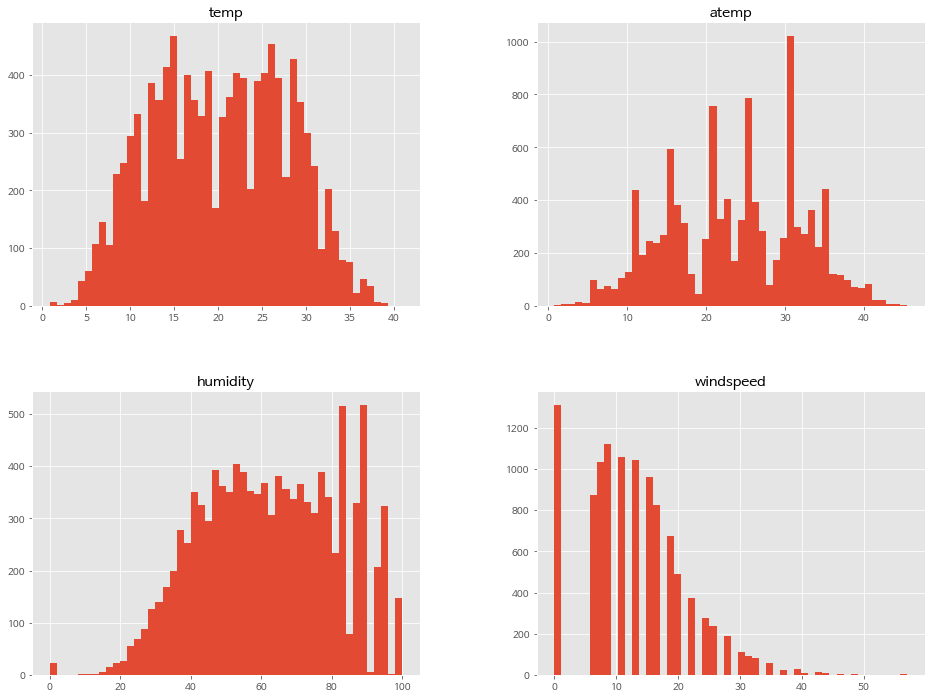

In [8]:
fig, ax = plt.subplots(figsize=(16,12))
 
# temp, atemp, humidity, windspeed 의 히스토그램
train[['temp', 'atemp', 'humidity', 'windspeed']].hist(bins=50, ax=ax)
 
plt.show()

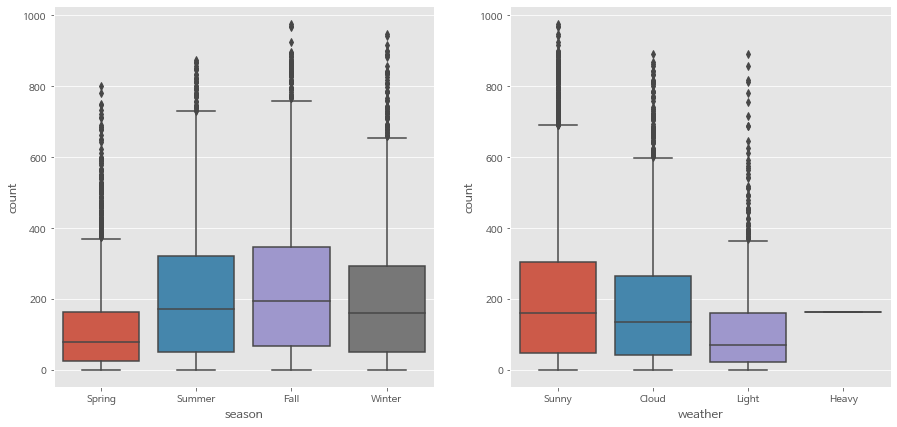

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15,7))
 
# season 와 weather 의 boxplot
sns.boxplot(data=train, x='season', y='count', ax=ax[0])
sns.boxplot(data=train, x='weather', y='count', ax=ax[1])
 
#x축 이름 변경
ax[0].set(xticklabels=['Spring', 'Summer', 'Fall', 'Winter'])
ax[1].set(xticklabels=['Sunny', 'Cloud', 'Light', 'Heavy'])
 
plt.show()

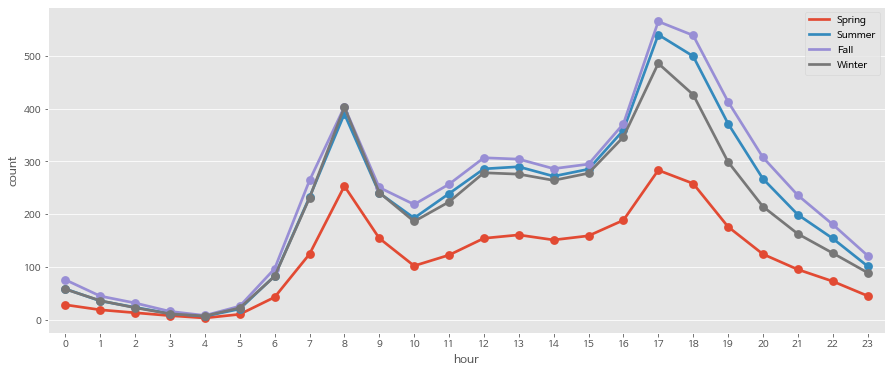

In [11]:
fig, ax = plt.subplots(figsize=(15,6))
 
# 계절에 따른 시간별 대여량
sns.pointplot(data=train, x='hour', y='count',hue='season', ax=ax, ci=None)
 
# x축 값이름 변경
labels=['Spring', 'Summer', 'Fall', 'Winter']
ax.legend(labels=labels)
 
plt.show()

In [13]:
# 계절과 월의 교차표
pd.crosstab(train['season'], train['month'])

month,1,2,3,4,5,6,7,8,9,10,11,12
season,,,,,,,,,,,,
1,884,901,901,0,0,0,0,0,0,0,0,0
2,0,0,0,909,912,912,0,0,0,0,0,0
3,0,0,0,0,0,0,912,912,909,0,0,0
4,0,0,0,0,0,0,0,0,0,911,911,912


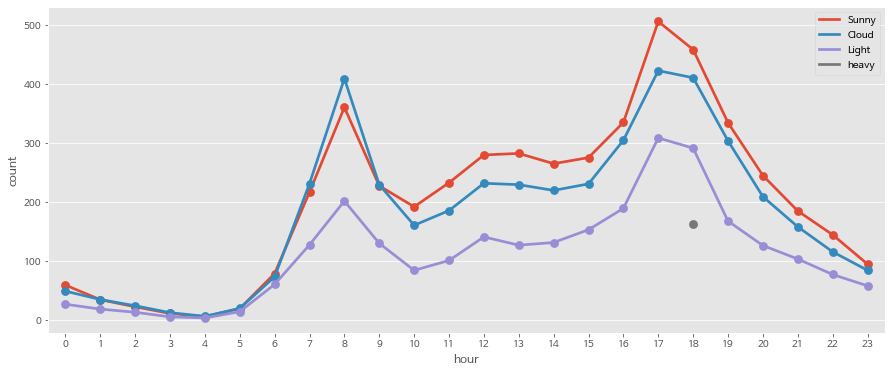

In [17]:
fig, ax = plt.subplots(figsize=(15,6))
 
# 날씨에 따른 시간별 대여량
sns.pointplot(data=train, x='hour', y='count',hue='weather', ax=ax, ci=None)
 
# x축 값이름 변경
labels=['Sunny', 'Cloud', 'Light', 'heavy']
ax.legend(labels=labels)
 
plt.show()

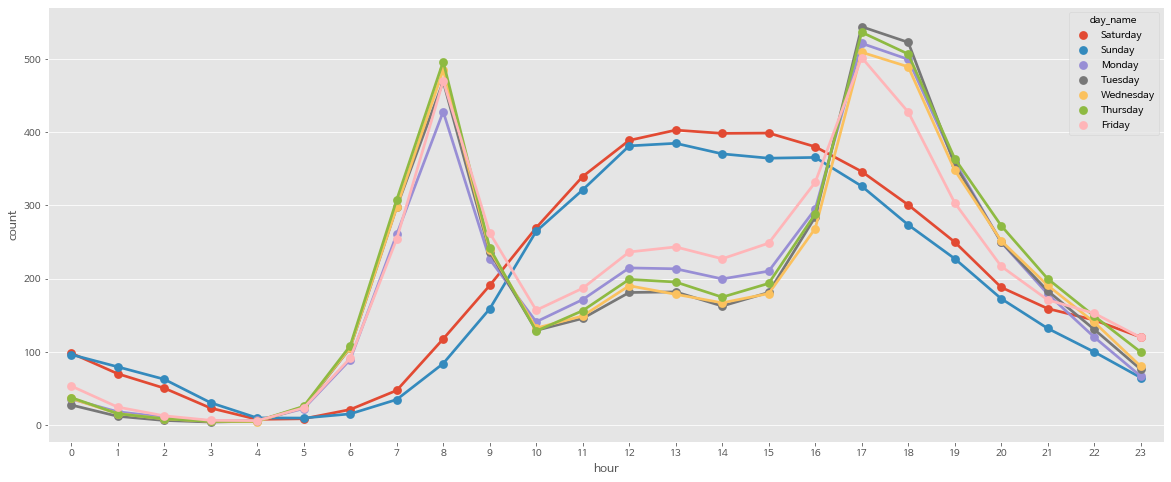

In [18]:
# 요일이름 Feature 만들기
train['day_name'] = train['datetime'].dt.day_name()
 
fig, ax = plt.subplots(figsize=(20,8))
 
# 요일에 따른 시간별 대여량
sns.pointplot(data=train, x='hour', y='count',hue='day_name', ax=ax, ci=None)
 
plt.show()

In [14]:
train["dayofweek"] = train["datetime"].dt.dayofweek
train["dayofweek"].value_counts()

5    1584
6    1579
3    1553
0    1551
2    1551
1    1539
4    1529
Name: dayofweek, dtype: int64

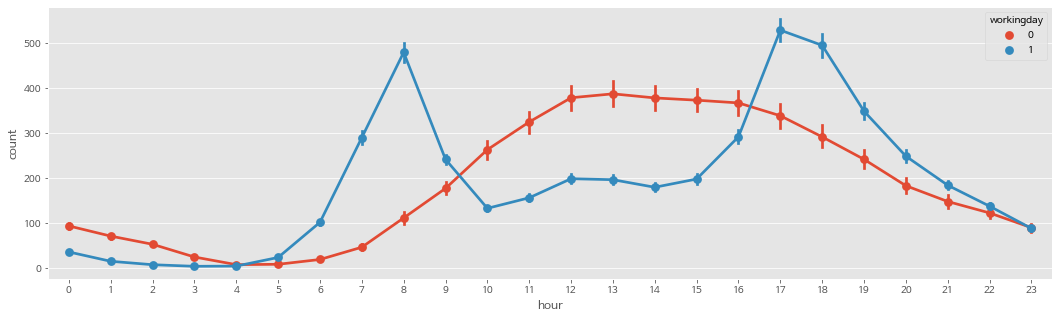

In [25]:
fig,(ax1)= plt.subplots(nrows=1)
fig.set_size_inches(18,5)
sns.pointplot(data=train, x="hour", y="count", hue="workingday", ax=ax1)

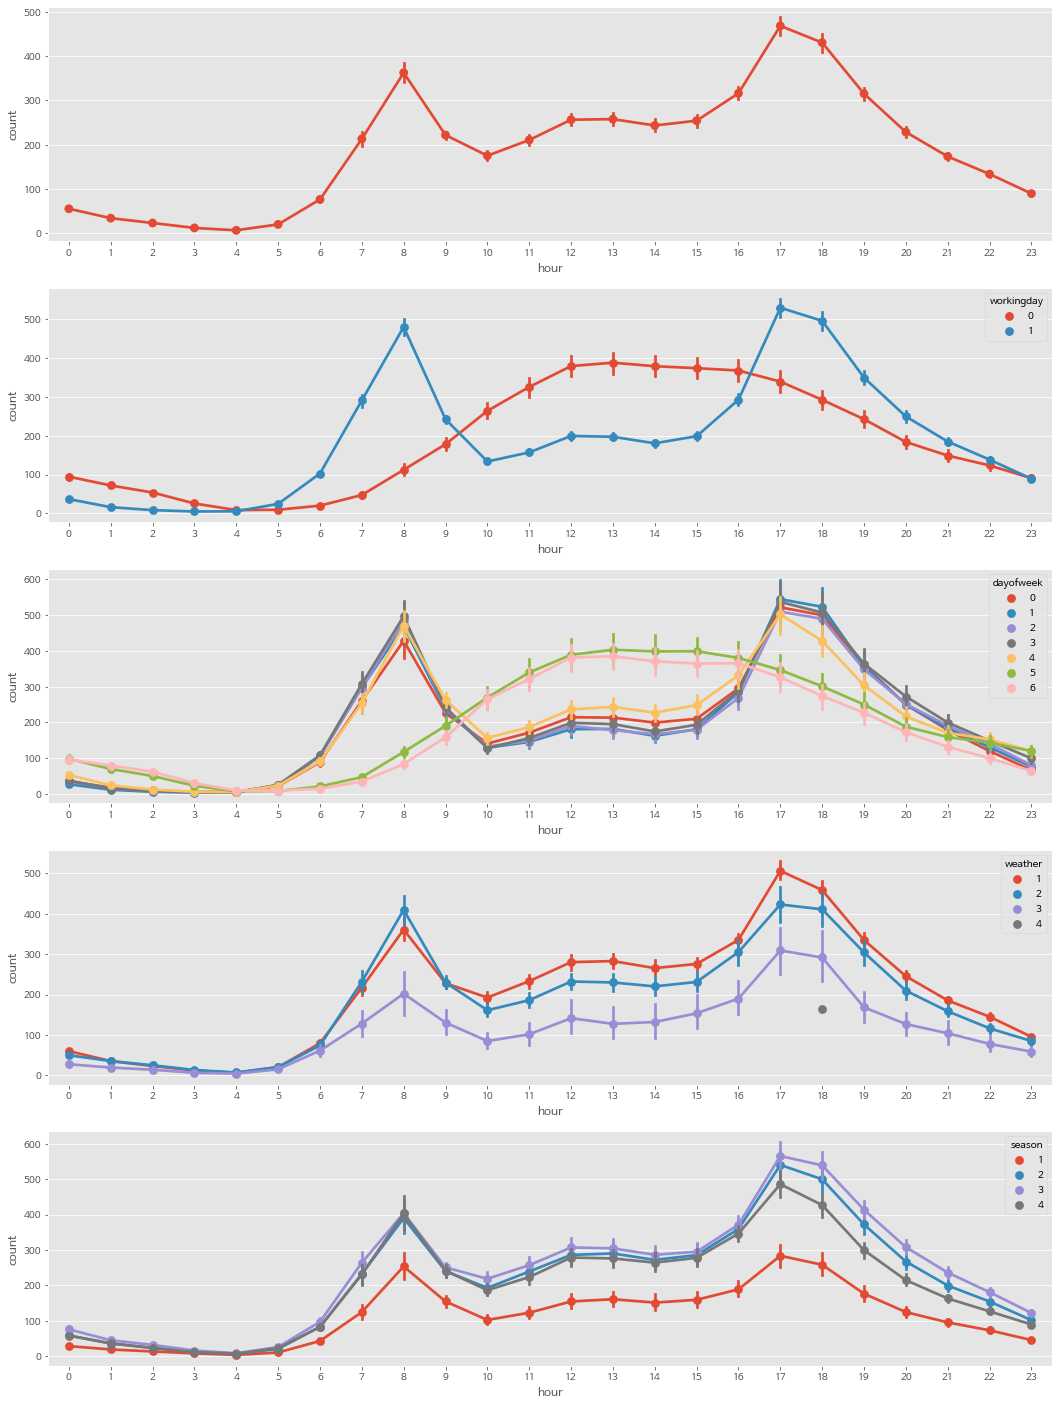

In [16]:
fig,(ax1,ax2,ax3,ax4,ax5)= plt.subplots(nrows=5)
fig.set_size_inches(18,25)

sns.pointplot(data=train, x="hour", y="count", ax=ax1)

sns.pointplot(data=train, x="hour", y="count", hue="workingday", ax=ax2)

sns.pointplot(data=train, x="hour", y="count", hue="dayofweek", ax=ax3)

sns.pointplot(data=train, x="hour", y="count", hue="weather", ax=ax4)

sns.pointplot(data=train, x="hour", y="count", hue="season", ax=ax5)


In [28]:
corrMatt = train[["temp", "atemp", "casual", "registered", "humidity", "windspeed", "count"]]
corrMatt = corrMatt.corr()
print(corrMatt)

mask = np.array(corrMatt)
mask[np.tril_indices_from(mask)] = False

                temp     atemp    casual  registered  humidity  windspeed  \
temp        1.000000  0.984948  0.467097    0.318571 -0.064949  -0.017852   
atemp       0.984948  1.000000  0.462067    0.314635 -0.043536  -0.057473   
casual      0.467097  0.462067  1.000000    0.497250 -0.348187   0.092276   
registered  0.318571  0.314635  0.497250    1.000000 -0.265458   0.091052   
humidity   -0.064949 -0.043536 -0.348187   -0.265458  1.000000  -0.318607   
windspeed  -0.017852 -0.057473  0.092276    0.091052 -0.318607   1.000000   
count       0.394454  0.389784  0.690414    0.970948 -0.317371   0.101369   

               count  
temp        0.394454  
atemp       0.389784  
casual      0.690414  
registered  0.970948  
humidity   -0.317371  
windspeed   0.101369  
count       1.000000  


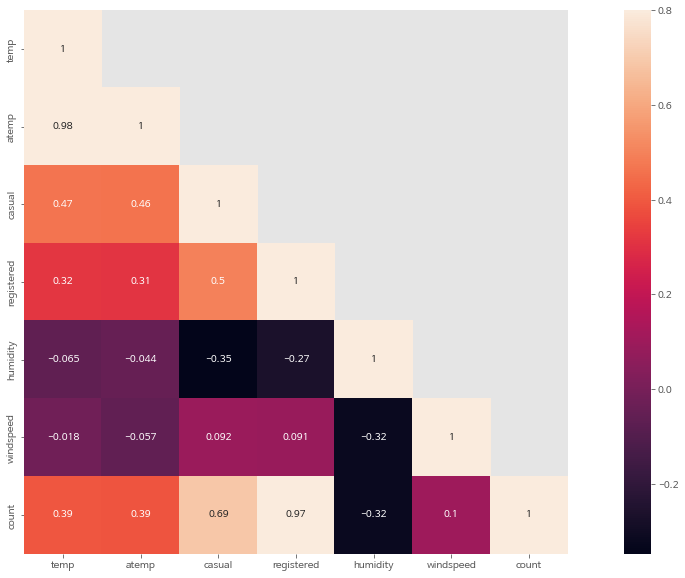

In [29]:
fig, ax = plt.subplots()
fig.set_size_inches(20,10)
sns.heatmap(corrMatt, mask=mask,vmax=.8, square=True,annot=True)


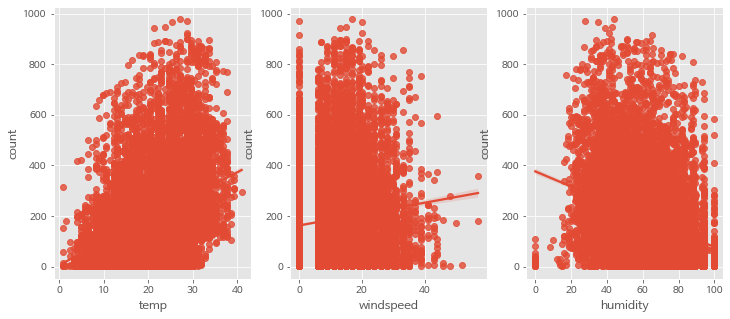

In [30]:
fig,(ax1,ax2,ax3) = plt.subplots(ncols=3)
fig.set_size_inches(12, 5)
sns.regplot(x="temp", y="count", data=train,ax=ax1)
sns.regplot(x="windspeed", y="count", data=train,ax=ax2)
sns.regplot(x="humidity", y="count", data=train,ax=ax3)


In [31]:
def concatenate_year_month(datetime):
    return "{0}-{1}".format(datetime.year, datetime.month)

train["year_month"] = train["datetime"].apply(concatenate_year_month)

print(train.shape)
train[["datetime", "year_month"]].head()

(10886, 21)


,datetime,year_month
0,2011-01-01 00:00:00,2011-1
1,2011-01-01 01:00:00,2011-1
2,2011-01-01 02:00:00,2011-1
3,2011-01-01 03:00:00,2011-1
4,2011-01-01 04:00:00,2011-1


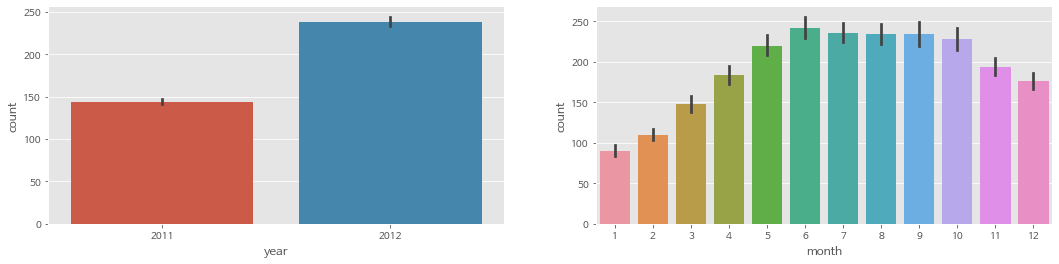

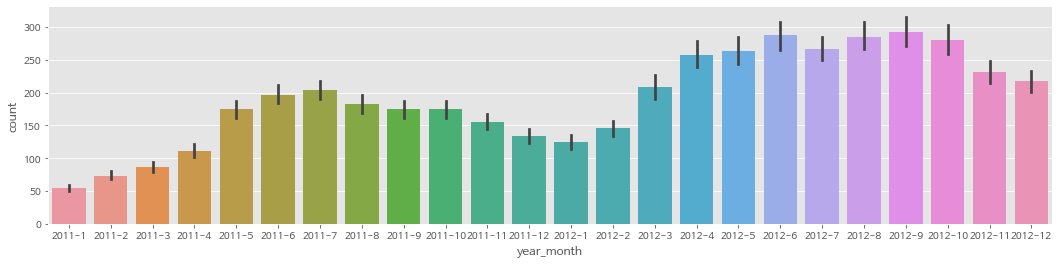

In [32]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(18, 4)

sns.barplot(data=train, x="year", y="count", ax=ax1)
sns.barplot(data=train, x="month", y="count", ax=ax2)

fig, ax3 = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(18, 4)

sns.barplot(data=train, x="year_month", y="count", ax=ax3)


In [34]:
# trainWithoutOutliers
trainWithoutOutliers = train[np.abs(train["count"] - train["count"].mean()) <= (3*train["count"].std())]

print(train.shape)
print(trainWithoutOutliers.shape)

(10886, 21)
(10739, 21)


/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


((array([-3.82819677, -3.60401975, -3.48099008, ...,  3.48099008,
          3.60401975,  3.82819677]),
  array([0.69314718, 0.69314718, 0.69314718, ..., 6.5971457 , 6.59850903,
         6.5998705 ])),
 (1.3486990121229776, 4.562423868087808, 0.9581176780909617))

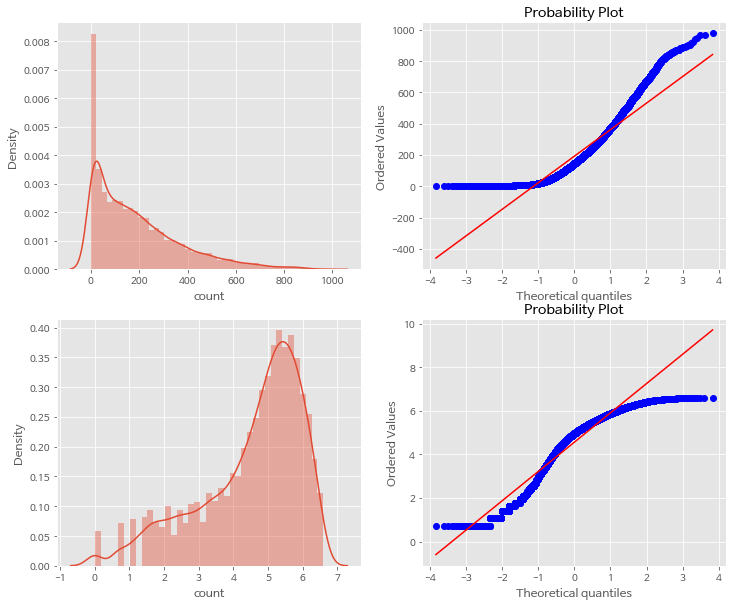

In [35]:
# count값의 데이터 분포도를 파악

figure, axes = plt.subplots(ncols=2, nrows=2)
figure.set_size_inches(12, 10)

sns.distplot(train["count"], ax=axes[0][0])
stats.probplot(train["count"], dist='norm', fit=True, plot=axes[0][1])
sns.distplot(np.log(trainWithoutOutliers["count"]), ax=axes[1][0])
stats.probplot(np.log1p(trainWithoutOutliers["count"]), dist='norm', fit=True, plot=axes[1][1])


/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


((array([-3.82819677, -3.60401975, -3.48099008, ...,  3.48099008,
          3.60401975,  3.82819677]),
  array([0.69314718, 0.69314718, 0.69314718, ..., 6.5971457 , 6.59850903,
         6.5998705 ])),
 (1.3486990121229776, 4.562423868087808, 0.9581176780909617))

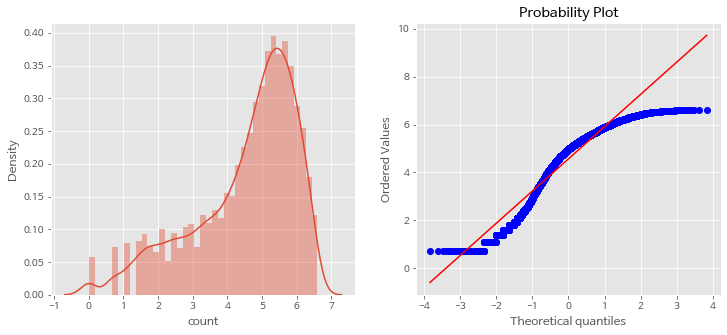

In [51]:
figure, axes = plt.subplots(ncols=2, nrows=1)
figure.set_size_inches(12, 5)


sns.distplot(np.log(trainWithoutOutliers["count"]), ax=axes[0])
stats.probplot(np.log1p(trainWithoutOutliers["count"]), dist='norm', fit=True, plot=axes[1])

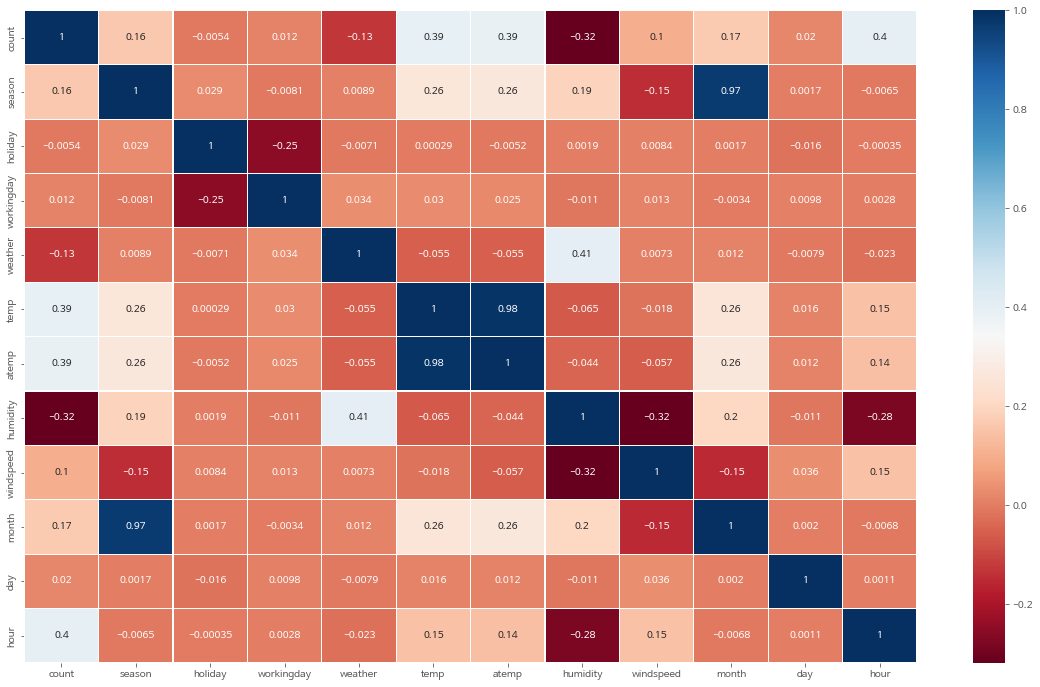

In [53]:
# 상관관계에 사용할 Feature 지정
corr_train = train[['count', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'month', 'day', 'hour']].corr()
 
fig, ax = plt.subplots(figsize=(20,12))
 
# heatmap
sns.heatmap(data=corr_train, ax=ax, linewidths=0.1, linecolor='white', annot=True, cmap=plt.cm.RdBu)
 
plt.show()

In [54]:
# datetime, day, day_name, year 제거
train.drop(['datetime', 'day', 'day_name', 'year'], inplace=True, axis=1)
 
# month, hour 은 범주형으로 변경
train['month'] = train['month'].astype('category')
train['hour'] = train['hour'].astype('category')
 
train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,minute,second,dayofweek,year_month
0,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,0,0,5,2011-1
1,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,0,0,5,2011-1
2,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,0,0,5,2011-1
3,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,0,0,5,2011-1
4,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,0,0,5,2011-1


In [56]:
# atemp 제거
train.drop('atemp', inplace=True, axis=1)
 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   holiday     10886 non-null  int64   
 1   workingday  10886 non-null  int64   
 2   temp        10886 non-null  float64 
 3   humidity    10886 non-null  int64   
 4   windspeed   10886 non-null  float64 
 5   count       10886 non-null  int64   
 6   month       10886 non-null  category
 7   hour        10886 non-null  category
 8   minute      10886 non-null  int64   
 9   second      10886 non-null  int64   
 10  dayofweek   10886 non-null  int64   
 11  year_month  10886 non-null  object  
 12  season_1    10886 non-null  uint8   
 13  season_2    10886 non-null  uint8   
 14  season_3    10886 non-null  uint8   
 15  season_4    10886 non-null  uint8   
 16  weather_1   10886 non-null  uint8   
 17  weather_2   10886 non-null  uint8   
 18  weather_3   10886 non-null  uint8   
 19  weat

In [59]:
train.head(0)

,holiday,workingday,temp,humidity,windspeed,count,month,hour,minute,second,dayofweek,year_month,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,0,0,9.84,81,0.0000,16,1,0,0,0,5,2011-1,1,0,0,0,1,0,0,0
1,0,0,9.02,80,0.0000,40,1,1,0,0,5,2011-1,1,0,0,0,1,0,0,0
2,0,0,9.02,80,0.0000,32,1,2,0,0,5,2011-1,1,0,0,0,1,0,0,0
3,0,0,9.84,75,0.0000,13,1,3,0,0,5,2011-1,1,0,0,0,1,0,0,0
4,0,0,9.84,75,0.0000,1,1,4,0,0,5,2011-1,1,0,0,0,1,0,0,0
5,0,0,9.84,75,6.0032,1,1,5,0,0,5,2011-1,1,0,0,0,0,1,0,0
6,0,0,9.02,80,0.0000,2,1,6,0,0,5,2011-1,1,0,0,0,1,0,0,0
7,0,0,8.20,86,0.0000,3,1,7,0,0,5,2011-1,1,0,0,0,1,0,0,0
8,0,0,9.84,75,0.0000,8,1,8,0,0,5,2011-1,1,0,0,0,1,0,0,0
9,0,0,13.12,76,0.0000,14,1,9,0,0,5,2011-1,1,0,0,0,1,0,0,0


In [64]:
train = pd.read_csv("./train.csv", parse_dates=["datetime"])
test = pd.read_csv("./test.csv", parse_dates=["datetime"])
train.shape, test.shape

((10886, 12), (6493, 9))

In [65]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [66]:
# datetime 타입으로 변경
train['datetime'] = pd.to_datetime(train['datetime'])
 
# month와 hour 추출
train['month'] = train['datetime'].dt.month
train['hour'] = train['datetime'].dt.hour
 
# month와 hour 범주화 타입으로 변경
train['month'] = train['month'].astype('category')
train['hour'] = train['hour'].astype('category')
 
# One-hot encoding
train = pd.get_dummies(train, columns=['season','weather'])
 
# 사용하지 않는 feature 삭제
drop_feature = ['datetime', 'atemp','casual','registered']
train.drop(drop_feature, inplace=True, axis=1)
 
train.head()

,holiday,workingday,temp,humidity,windspeed,count,month,hour,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,0,0,9.84,81,0.0,16,1,0,1,0,0,0,1,0,0,0
1,0,0,9.02,80,0.0,40,1,1,1,0,0,0,1,0,0,0
2,0,0,9.02,80,0.0,32,1,2,1,0,0,0,1,0,0,0
3,0,0,9.84,75,0.0,13,1,3,1,0,0,0,1,0,0,0
4,0,0,9.84,75,0.0,1,1,4,1,0,0,0,1,0,0,0


In [67]:
# datetime 타입으로 변경
test['datetime'] = pd.to_datetime(test['datetime'])
 
# month와 hour 추출
test['month'] = test['datetime'].dt.month
test['hour'] = test['datetime'].dt.hour
 
# month와 hour 범주화 타입으로 변경
test['month'] = test['month'].astype('category')
test['hour'] = test['hour'].astype('category')
 
# One-hot encoding
test = pd.get_dummies(test, columns=['season','weather'])
 
# 사용하지 않는 feature 삭제
drop_feature = ['datetime', 'atemp']
test.drop(drop_feature, inplace=True, axis=1)
 
test.head()

,holiday,workingday,temp,humidity,windspeed,month,hour,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,0,1,10.66,56,26.0027,1,0,1,0,0,0,1,0,0,0
1,0,1,10.66,56,0.0000,1,1,1,0,0,0,1,0,0,0
2,0,1,10.66,56,0.0000,1,2,1,0,0,0,1,0,0,0
3,0,1,10.66,56,11.0014,1,3,1,0,0,0,1,0,0,0
4,0,1,10.66,56,11.0014,1,4,1,0,0,0,1,0,0,0


In [73]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   holiday     10886 non-null  int64   
 1   workingday  10886 non-null  int64   
 2   temp        10886 non-null  float64 
 3   humidity    10886 non-null  int64   
 4   windspeed   10886 non-null  float64 
 5   count       10739 non-null  float64 
 6   month       10886 non-null  category
 7   hour        10886 non-null  category
 8   season_1    10886 non-null  uint8   
 9   season_2    10886 non-null  uint8   
 10  season_3    10886 non-null  uint8   
 11  season_4    10886 non-null  uint8   
 12  weather_1   10886 non-null  uint8   
 13  weather_2   10886 non-null  uint8   
 14  weather_3   10886 non-null  uint8   
 15  weather_4   10886 non-null  uint8   
dtypes: category(2), float64(3), int64(3), uint8(8)
memory usage: 617.8 KB


In [153]:
X_train  = train.drop('count',axis=1)
X_test  = test[:]
y_train = train['count']

In [ ]:
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.linear_model import LinearRegression , Ridge , Lasso, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# log 값 변환 시 NaN등의 이슈로 log() 가 아닌 log1p() 를 이용하여 RMSLE 계산
def rmsle(y, pred):
    log_y = np.log1p(y)
    log_pred = np.log1p(pred)
    squared_error = (log_y - log_pred) ** 2
    rmsle = np.sqrt(np.mean(squared_error))
    return rmsle

# 사이킷런의 mean_square_error() 를 이용하여 RMSE 계산
def rmse(y,pred):
    return np.sqrt(mean_squared_error(y,pred))

# MSE, RMSE, RMSLE 를 모두 계산 
def evaluate_regr(y,pred):
    rmsle_val = rmsle(y,pred)
    rmse_val = rmse(y,pred)
    # MAE 는 scikit learn의 mean_absolute_error() 로 계산
    mae_val = mean_absolute_error(y,pred)
    print('RMSLE: {0:.3f}, RMSE: {1:.3F}, MAE: {2:.3F}'.format(rmsle_val, rmse_val, mae_val))

# 모델과 학습/테스트 데이터 셋을 입력하면 성능 평가 수치를 반환
def get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1=False):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    if is_expm1 :
        y_test = np.expm1(y_test)
        pred = np.expm1(pred)
    print('###',model.__class__.__name__,'###')
    evaluate_regr(y_test, pred)
# end of function get_model_predict  

In [154]:
# y_train_log = np.log1p(y_train)
X_train, x_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.3, random_state=0)

# model 별로 평가 수행
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.01)
rfModel = RandomForestRegressor(n_estimators=100)

for model in [lr_reg, ridge_reg, lasso_reg, rfModel]:
    get_model_predict(model,X_train, x_test, y_train, y_test,is_expm1=True)

### LinearRegression ###
RMSLE: 0.703, RMSE: 436.905, MAE: 118.438
### Ridge ###
RMSLE: 0.703, RMSE: 436.903, MAE: 118.441
### Lasso ###
RMSLE: 0.704, RMSE: 436.731, MAE: 118.555
### RandomForestRegressor ###
RMSLE: 0.017, RMSE: 3.412, MAE: 1.332


In [156]:
params ={
    'n_estimators':[10,30,50, 100],
    'max_depth':[6,8,10,12],
    'min_samples_leaf':[8,12,18],
    'min_samples_split':[8,16,20]
}

rfr = RandomForestRegressor()
grid_cv = GridSearchCV(rfr, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train,y_train)

print(f"Best Param: {grid_cv.best_params_}")
max_depth = grid_cv.best_params_['max_depth']
min_samples_leaf = grid_cv.best_params_['min_samples_leaf']
min_samples_split = grid_cv.best_params_['min_samples_split']
n_estimators = grid_cv.best_params_['n_estimators']


Best Param: {'max_depth': 12, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}


In [158]:
predsTest = lr_reg.predict(X_test)
submission = pd.read_csv("./sampleSubmission.csv")
submission["count"] = np.exp(predsTest)
submission.to_csv("./Score_lr_reg_submission.csv".format(score), index=False)

print(submission.shape)
submission.head()

(6493, 2)


,datetime,count
0,2011-01-20 00:00:00,16.373076
1,2011-01-20 01:00:00,16.378562
2,2011-01-20 02:00:00,17.183082
3,2011-01-20 03:00:00,18.035373
4,2011-01-20 04:00:00,19.084335


In [157]:
predsTest = grid_cv.predict(X_test)
submission = pd.read_csv("./sampleSubmission.csv")
submission["count"] = np.exp(predsTest)
submission.to_csv("./Score_best_param_submission.csv".format(score), index=False)

print(submission.shape)
submission.head()

(6493, 2)


,datetime,count
0,2011-01-20 00:00:00,14.375597
1,2011-01-20 01:00:00,7.174274
2,2011-01-20 02:00:00,4.987641
3,2011-01-20 03:00:00,3.947220
4,2011-01-20 04:00:00,3.005976


In [155]:
predsTest = rfModel.predict(X_test)

submission = pd.read_csv("./sampleSubmission.csv")
submission["count"] = np.exp(predsTest)
submission.to_csv("./Score_{0:.5f}_submission.csv".format(score), index=False)

print(submission.shape)
submission.head()

(6493, 2)


,datetime,count
0,2011-01-20 00:00:00,14.038689
1,2011-01-20 01:00:00,7.000000
2,2011-01-20 02:00:00,5.000000
3,2011-01-20 03:00:00,4.000000
4,2011-01-20 04:00:00,3.000000
